# Нелинейная модель для предсказания отмены бронирования номеров в отеле

## Введение

<b>Бизнес контекст и цель проекта</b>  
Гостиничная сеть систематически сталкивается с проблемой отмен бронирования. Часто гостиница не успевает найти новых гостей и номер остается пустой, что наносит финансовый ущерб компании
  
<b>Цель проекта</b>  
Создание модели машинного обучения, способную спрогнозировать вероятность отмены бронировнаия. Модель должна минимизировать финансовые потери сети отелей и по возможности повышать загрузку номеров.

<b>Критерии успешности проекта:</b>
  - Доля отмен после внедрения модели: 10%
  - Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели
  - Относительный IR должен составить не менее 50%

<b>Формализация задачи машинного обучения</b>
  - <b>Объект наблюдения:</b> данные о бронировании
  - <b>Целевая переменная:</b> бинарный признак - обозначающий текущий статус бронирования
  - <b>Тип задачи:</b> бинарная классификация

<b>План исследования:</b>
  1. Ознакомление с данными
  2. Предобработка и очистка
  3. Исследовательский анализ данных
  4. Подготовка даннах к моделированию
  5. Построение моделей и валидация
  6. Подбор гиперпараметров
  7. Сравнение и выбор лучшей модели
  8. Калибровка вероятностей
  9. Подбор порога классификации
  10. Анализ матрицы ошибок

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

In [1]:
!pip install dotenv
!pip install phik
!pip install nltk
!pip install optuna
!pip install shap

     |████████████████████████████████| 677 kB 2.6 MB/s eta 0:00:01
     |████████████████████████████████| 419 kB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 999 kB 2.7 MB/s eta 0:00:01


In [2]:
from sqlalchemy.engine import URL, create_engine
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, TimeSeriesSplit
import nltk
nltk.download('stopwords') 
from nltk.corpus import stopwords
import time
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
from sklearn.metrics import confusion_matrix, brier_score_loss, roc_auc_score, make_scorer, classification_report, average_precision_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
from sklearn.base import clone

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
RANDOM_SEED=42
AvgRev = 64_500 # Средняя выручка с номера
CostFP = 7_000 # Компесация гостю
LostRev = 64_500 # упущенный доход от отмены бронирования
PerRebooking = 45_000 # стоимость повторной сдачи номера, бронь на который отменилась

In [4]:
# !pip freeze > requirements.txt

## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

In [5]:
load_dotenv()

url_object = URL.create(
    host=os.getenv('HOST'),
    database=os.getenv('DATABASE'),
    port=int(os.getenv('PORT')),
    username=os.getenv('USER'),
    password=os.getenv('PASSWORD'),
    drivername='postgresql'
)

engine = create_engine(url_object)

hotel_bookings = pd.read_sql("SELECT * FROM hotel_bookings", engine)
hotel_reviews = pd.read_sql("SELECT * FROM hotel_reviews", engine)

In [6]:
hotel_bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  str    
 14  p

In [7]:
hotel_bookings.describe()

,adult_count,child_count,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,customer_special_requests
count,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000
mean,12.479726,0.358988,0.356923,0.839535,61634.055219,100.523726,6.532922,1.953991,0.621488
std,45.726290,0.587324,0.628771,0.931724,42837.589968,71.872677,3.339492,1.477249,0.784391
min,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,33500.000000,45.000000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,1.000000,53600.000000,90.000000,6.000000,2.000000,0.000000
75%,3.000000,1.000000,1.000000,1.000000,80400.000000,144.000000,9.000000,2.000000,1.000000
max,300.000000,2.000000,5.000000,5.000000,417221.200000,300.000000,15.000000,6.000000,5.000000


In [8]:
hotel_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  str   
dtypes: int64(1), object(1), str(3)
memory usage: 983.6+ KB


In [9]:
hotel_reviews.describe()

,stay_rating
count,25177.000000
mean,3.395321
std,0.541434
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


In [10]:
print(f'Самая раняя дата бронирования: {hotel_bookings['booking_date'].min()}')
print(f'Самая поздняя дата бронирования: {hotel_bookings['booking_date'].max()}')
print()
print(f'Самая раняя дата отзыва: {hotel_reviews['review_date'].min()}')
print(f'Самая поздняя дата отзыва: {hotel_reviews['review_date'].max()}')

Самая раняя дата бронирования: 2017-01-01
Самая поздняя дата бронирования: 2025-10-22

Самая раняя дата отзыва: 2017-01-17
Самая поздняя дата отзыва: 2026-03-03


Комментарии по выгруженным данным:
  - Таблица hotel_bookings представлена 35341 строкой и 17 столбцами, в которых содержатся данные о состоянии и подробности бронирования номеров
  - Таблица hotel_reviews представлена 25177 строкой и 5 столбцами, в которых содержатся данные об отзывах клиентов и их оценка отеля

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [11]:
def pie_diagram(labels, sizes, title):
    """ Для построения круговых диаграм """
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1)
    plt.title(title)
    plt.show()


def histplot(data, x, title, x_label, y_label, rotation=0, size=(8, 4), bins=False):
    """ Для построения гистограм """
    plt.figure(figsize=size)
    sns.histplot(data=data, x=x, bins=bins if bins else 'auto')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.show()


In [12]:
print(f'Количество полных дубликатов в hotel_bookings: {hotel_bookings.duplicated().sum()}')
hotel_bookings = hotel_bookings.drop_duplicates()

Количество полных дубликатов в hotel_bookings: 4608


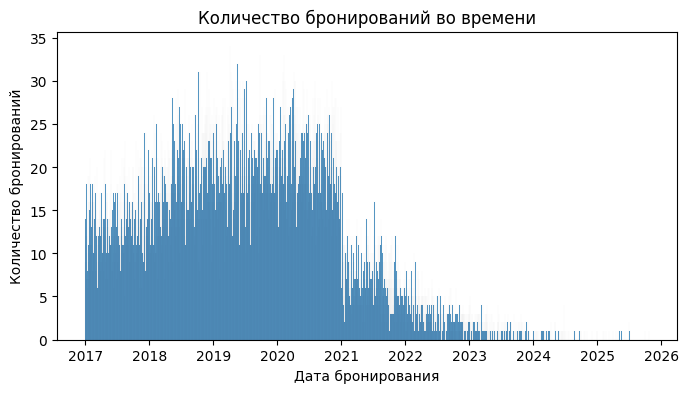

In [13]:
histplot(hotel_bookings,
         'booking_date',
         "Количество бронирований во времени",
         "Дата бронирования",
         "Количество бронирований")

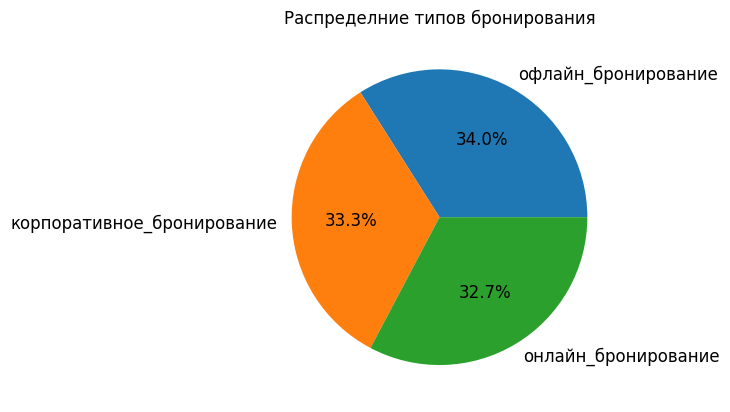

In [14]:
pie_diagram(hotel_bookings['sales_channel'].value_counts().index,
            hotel_bookings['sales_channel'].value_counts().values,
            'Распределние типов бронирования')

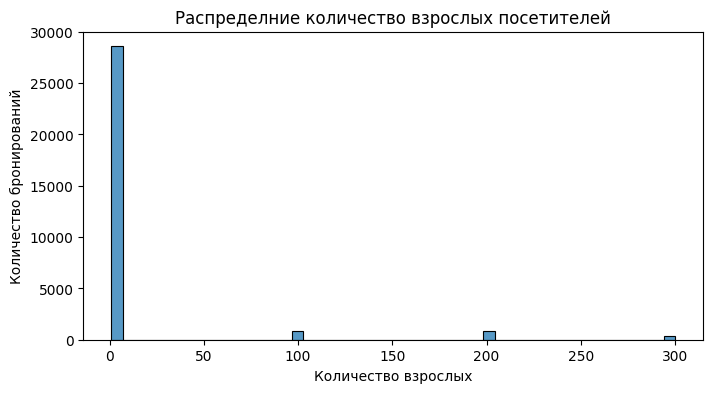

In [15]:
histplot(hotel_bookings,
         "adult_count",
         "Распределние количество взрослых посетителей",
         "Количество взрослых",
         "Количество бронирований",
         bins=50)

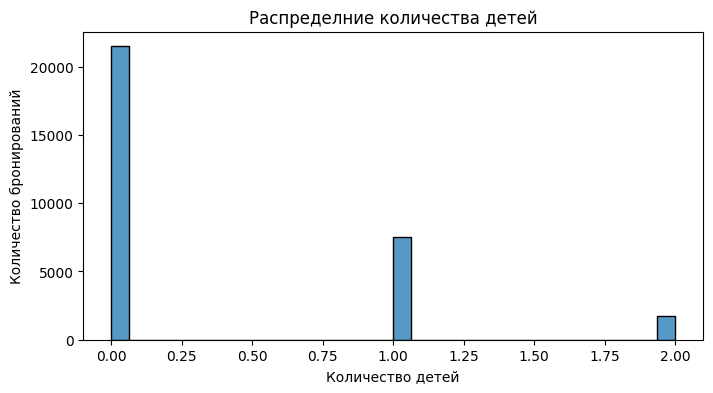

In [16]:
histplot(hotel_bookings,
         "child_count",
         "Распределние количества детей",
         "Количество детей",
         "Количество бронирований",)

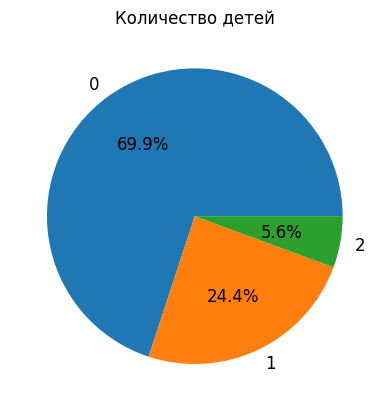

In [17]:
pie_diagram(hotel_bookings['child_count'].value_counts().index,
            hotel_bookings['child_count'].value_counts().values,
            'Количество детей')

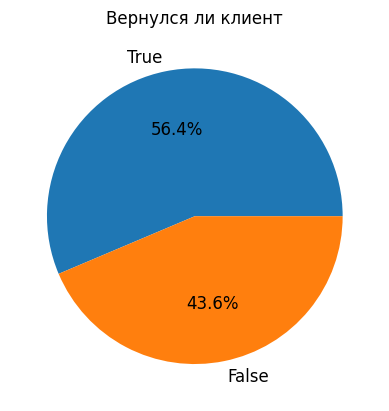

In [18]:
pie_diagram(hotel_bookings['returning_customer'].value_counts().index,
            hotel_bookings['returning_customer'].value_counts().values,
            'Вернулся ли клиент')

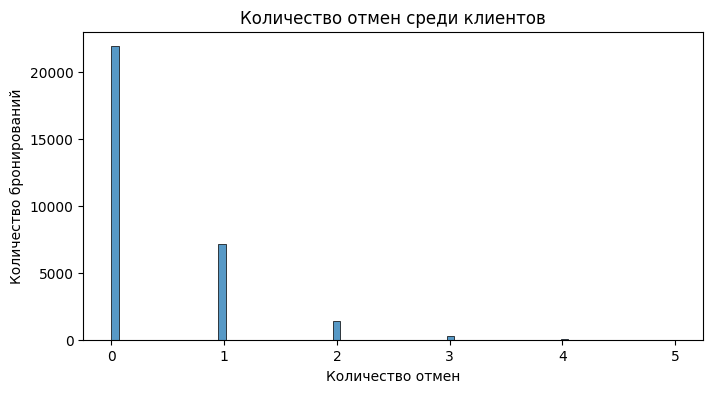

In [19]:
histplot(hotel_bookings,
         "previous_cancellations",
         "Количество отмен среди клиентов",
         "Количество отмен",
         "Количество бронирований",)

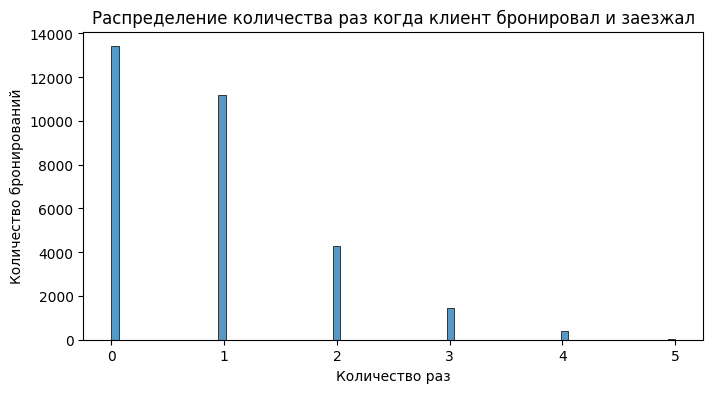

In [20]:
histplot(hotel_bookings,
         "previous_no_shows",
         "Распределение количества раз когда клиент бронировал и заезжал",
         "Количество раз",
         "Количество бронирований",)


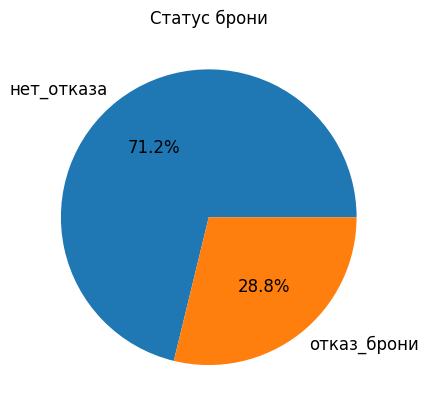

In [21]:
pie_diagram(hotel_bookings['booking_status'].value_counts().index,
            hotel_bookings['booking_status'].value_counts().values,
            'Статус брони')

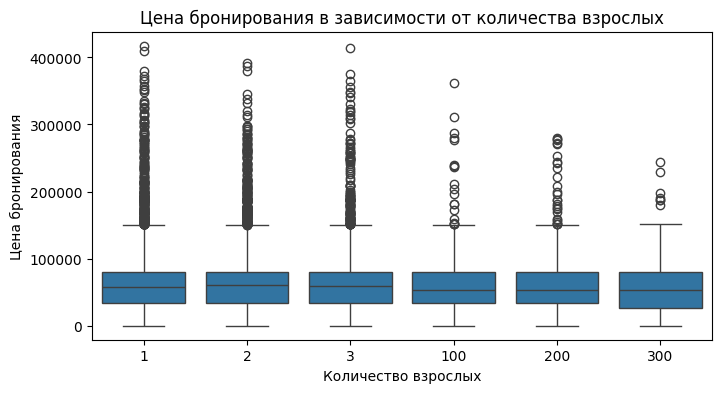

In [22]:
# booking_value
plt.figure(figsize=(8, 4))
sns.boxplot(data=hotel_bookings, x='adult_count', y='booking_value')
plt.title("Цена бронирования в зависимости от количества взрослых")
plt.xlabel("Количество взрослых")
plt.ylabel("Цена бронирования")
plt.show()

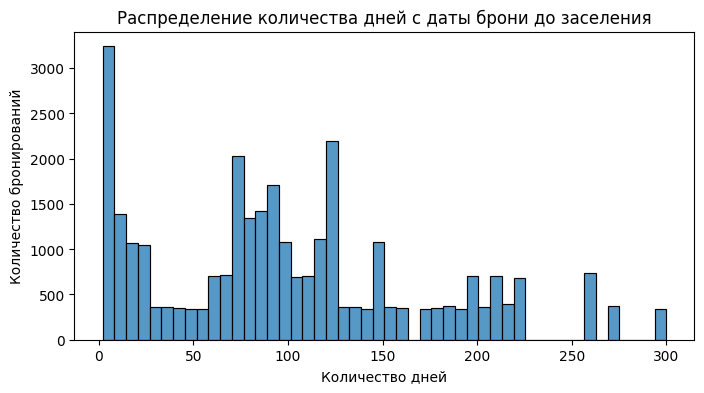

In [23]:
histplot(hotel_bookings,
         "days_until_checkin",
         "Распределение количества дней с даты брони до заселения",
         "Количество дней",
         "Количество бронирований",)

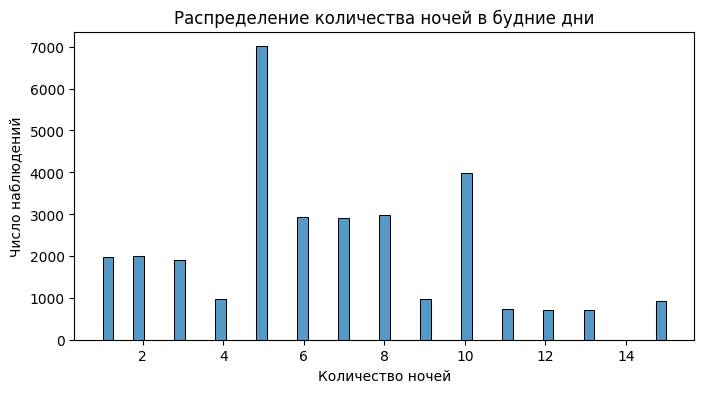

In [24]:
histplot(hotel_bookings,
         "weekday_nights",
         "Распределение количества ночей в будние дни",
         "Количество ночей",
         "Число наблюдений",)

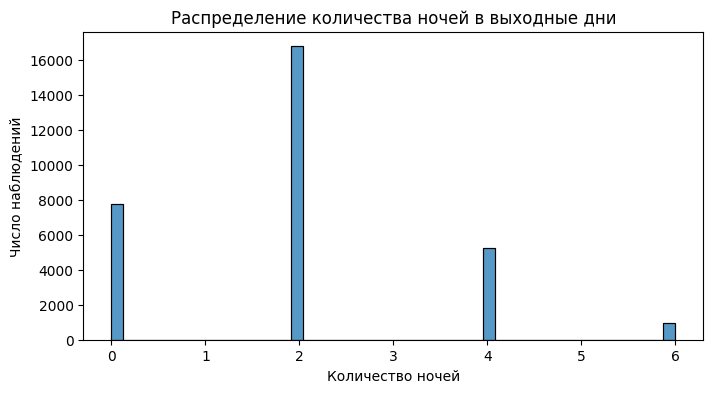

In [25]:
histplot(hotel_bookings,
         "weekend_nights",
         "Распределение количества ночей в выходные дни",
         "Количество ночей",
         "Число наблюдений",)

meal_plan
тип_питания_1    23604
не выбран         3868
тип_питания_2     2826
не выбрант         430
тип_питания_3        5
Name: count, dtype: int64
meal_plan
тип_питания_1    23604
не выбран         4298
тип_питания_2     2826
тип_питания_3        5
Name: count, dtype: int64


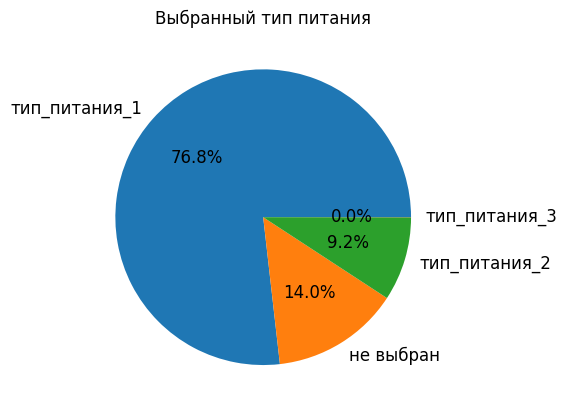

In [26]:
print(hotel_bookings['meal_plan'].value_counts())
# Исправляем ошибку в названии категории
hotel_bookings['meal_plan'] = hotel_bookings['meal_plan'].mask(hotel_bookings['meal_plan'] == 'не выбрант', 'не выбран')
print(hotel_bookings['meal_plan'].value_counts())

pie_diagram(hotel_bookings['meal_plan'].value_counts().index,
            hotel_bookings['meal_plan'].value_counts().values,
            'Выбранный тип питания')


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку!</font>

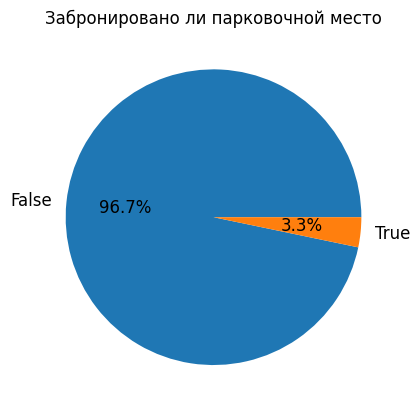

In [27]:
pie_diagram(hotel_bookings['parking_included'].value_counts().index,
            hotel_bookings['parking_included'].value_counts().values,
            'Забронировано ли парковочной место')

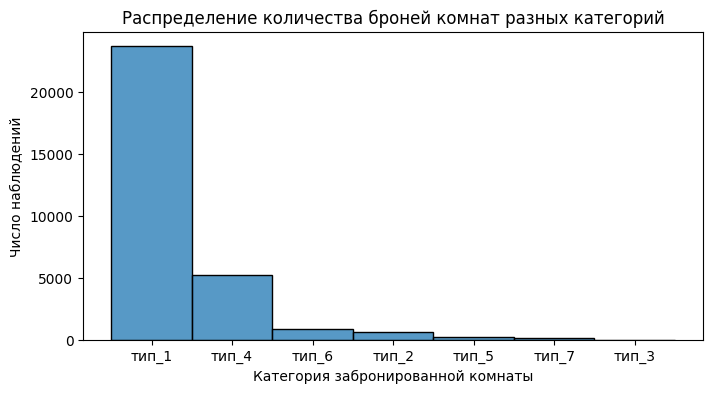

In [28]:
histplot(hotel_bookings,
         "room_type",
         "Распределение количества броней комнат разных категорий",
         "Категория забронированной комнаты",
         "Число наблюдений",)

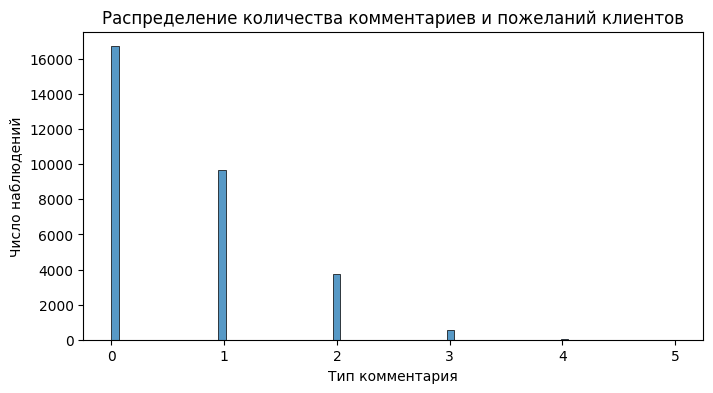

In [29]:
histplot(hotel_bookings,
         "customer_special_requests",
         "Распределение количества комментариев и пожеланий клиентов",
         "Тип комментария",
         "Число наблюдений",)


In [30]:
print(f"Количество наблюдений с нулевым booking_value: {len(hotel_bookings[hotel_bookings['booking_value']==0])}")

Количество наблюдений с нулевым booking_value: 1229


In [31]:
# Проверяем что это явно не связано с целевой переменной
hotel_bookings[hotel_bookings['booking_value']==0]['booking_status'].value_counts()

booking_status
нет_отказа     871
отказ_брони    358
Name: count, dtype: int64

In [32]:
# Удаляем строки с нулевым booking_value
hotel_bookings = hotel_bookings[hotel_bookings['booking_value'] > 0]

In [33]:
# Корректируем количество людей по правилу "если больше 99, то делим на 100"
hotel_bookings.loc[hotel_bookings['adult_count'] > 99, 'adult_count'] = hotel_bookings['adult_count'] / 100

In [34]:
hotel_bookings.info()

<class 'pandas.DataFrame'>
Index: 29504 entries, 0 to 30735
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 29504 non-null  str    
 1   booking_date               29504 non-null  object 
 2   sales_channel              29504 non-null  str    
 3   adult_count                29504 non-null  int64  
 4   child_count                29504 non-null  int64  
 5   returning_customer         29504 non-null  bool   
 6   previous_cancellations     29504 non-null  int64  
 7   previous_no_shows          29504 non-null  int64  
 8   booking_status             29504 non-null  str    
 9   booking_value              29504 non-null  float64
 10  days_until_checkin         29504 non-null  int64  
 11  weekday_nights             29504 non-null  int64  
 12  weekend_nights             29504 non-null  int64  
 13  meal_plan                  29504 non-null  str    
 14  parkin

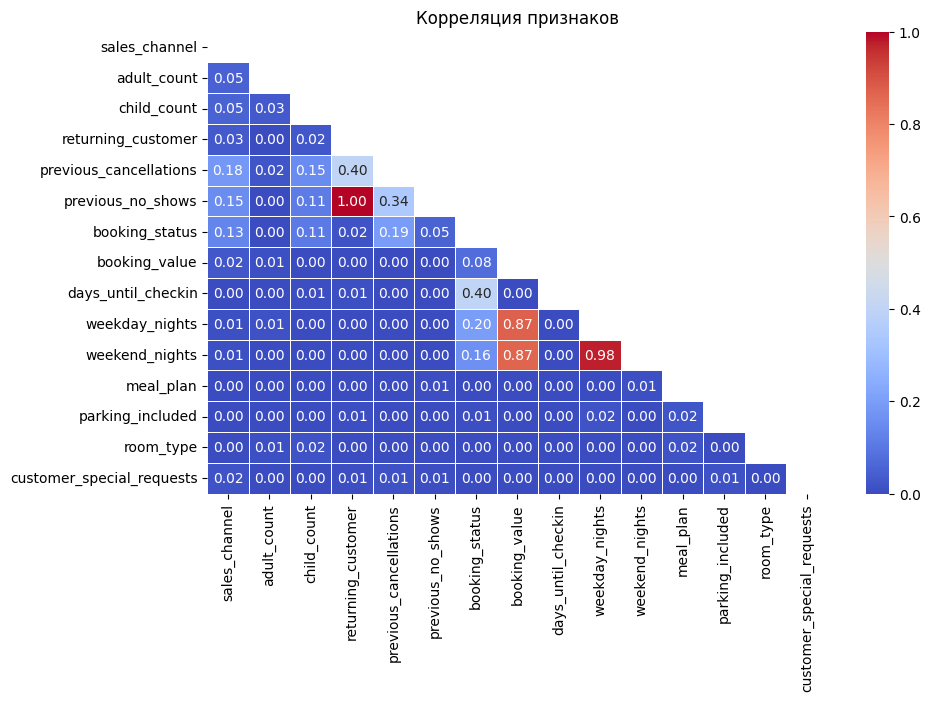

In [35]:
# Корреляция
interval_cols = ['adult_count', 'child_count', 'previous_cancellations',
                 'previous_no_shows', 'booking_value', 'days_until_checkin',
                 'weekday_nights', 'weekend_nights', 'customer_special_requests']

corr_data = hotel_bookings.drop(columns=['booking_id', 'booking_date']).phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков')
plt.show()

In [36]:
# На основе анализа корреляции удаляем признаки с высокой корреляцией
hotel_bookings = hotel_bookings.drop(columns=['returning_customer', 'weekend_nights'])

In [37]:
print(f'Количество полных дубликатов в hotel_reviews: {hotel_reviews.duplicated().sum()}')

Количество полных дубликатов в hotel_reviews: 0


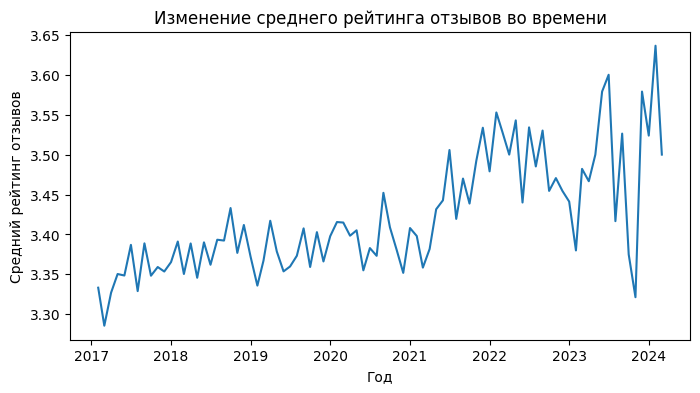

In [38]:
grouped = hotel_reviews.copy()
grouped['review_date'] = pd.to_datetime(grouped['review_date'])
grouped['month_year_period'] = grouped['review_date'].dt.to_period('M')
grouped['month_year_dt'] = grouped['month_year_period'].dt.to_timestamp()

grouped = grouped.groupby("month_year_dt")['stay_rating'].agg(['mean', 'count']).reset_index()

# Фильтр для месяцев с малым количеством отзывов
grouped = grouped[grouped['count'] > 9]
grouped = grouped.sort_values(by='month_year_dt', ascending=True)

plt.figure(figsize=(8, 4))
sns.lineplot(data=grouped, x='month_year_dt', y='mean')
plt.title("Изменение среднего рейтинга отзывов во времени")
plt.xlabel("Год")
plt.ylabel("Средний рейтинг отзывов")
plt.show()

Выводы по данным:
  - Таблица hotel_bookings:
    - Были обнаружены 4608 полных дубликатов, которые были удалены
    - Количество бронирований с начала 2021 года резко упало - с 15-25 до 5-10 бронирований в день
    - По типу, бронирования распределены примерно одинаково между офлайн, онлайн и корпоративным
    - В 69.9% случаев детей среди ожидаемых гостей нет, в 24.4% ожидается 1 ребенок, в 5.6% случаев - 2 ребенка
    - 56.4% клиентов уже бронировали номера в сети отелей
    - 71.2% клиентов ни разу не отменяли бронь, 23.2% отменяли 1 раз, 4.6% отменяли 2 раза, большее количество отмен является очень редким явлением
    - У 71.2% клиентов статус брони активно, т.е. не отменено, у 28.8% клиентов бронирование отменено - в целевой переменной наблюдается умеренная диспропорция классов
    - Медиана итоговой стоимости бронирования составляет 53_600 рублей. По видимому, количество человек не виляет на итоговую стоимость бронировния
    - Почти все бронирования приходятся на срок до 200 дней до даты заселения, при этом отмечаются периоды, в которых бронирование наиболее активно: период от нескольких дней до нескольких недель до заселения; период от 70 до 125 дней до заселения
    - Наиболее популярым количеством ночей в будние дни является период от 5 до 10 дней
    - Чаще всего клиенты остаются на 2 выходных ночи
    - 76.8% клиентов выбрирают тип питания 1, у 14% клиентов тип питания не выбран, 9.2% выбирают тип питания 2, на тип питания 3 приходится незначительная доля клиентов
    - Только 3.3% клиентов бронируют парковочное место
    - 77.1% клиентов бронируют тип номера 1, 17.1% бронируют тип 4, 2.7% бронируют тип 6, на остальные типы приходится незначительные (менее 1%) броней
    - Чаще всего клинеты не оставляют пожеланий и комментариев
    - В столбце booking_value обнаружено 1229 аномальных наблдений с нулевым значенем. Как выяснилось, подобные наблюдения не имеют ярко выраженной связи с целевой переменной, поэтому они были удалены.
    - В столбце adult_count были обнаружены аномальные наблюдения, в сотни раз превосходящие типичные значения. Такие значения были приведены к "нормальным" путем разделения на 100
    - В результате обработки дубликатов и аномальных значений было удалено 5837 наблюдений (16.5% от изначального датафрейма)
    - Для устранения мультиколлинеарности были удалены признаки returning_customer и weekend_nights
  - Таблица hotel_reviews:
    - Дубликатов в данных не обнаружены
    - Со временем, оценка клиентами проживания со временем медленно растет

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

In [39]:
hotel_bookings = hotel_bookings.merge(
    hotel_reviews[['booking_id', 'customer_id']].drop_duplicates(subset='booking_id'),
    on='booking_id',
    how='left'
)

In [40]:
hotel_bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 29504 non-null  str    
 1   booking_date               29504 non-null  object 
 2   sales_channel              29504 non-null  str    
 3   adult_count                29504 non-null  int64  
 4   child_count                29504 non-null  int64  
 5   previous_cancellations     29504 non-null  int64  
 6   previous_no_shows          29504 non-null  int64  
 7   booking_status             29504 non-null  str    
 8   booking_value              29504 non-null  float64
 9   days_until_checkin         29504 non-null  int64  
 10  weekday_nights             29504 non-null  int64  
 11  meal_plan                  29504 non-null  str    
 12  parking_included           29504 non-null  bool   
 13  room_type                  29504 non-null  str    
 14  c

In [41]:
print('Количество пересекающихся booking_id между таблицами:',
      len(set(hotel_bookings['booking_id']).intersection(set(hotel_reviews['booking_id']))))

Количество пересекающихся booking_id между таблицами: 21012


In [42]:
hotel_reviews['review_date'] = pd.to_datetime(hotel_reviews['review_date'])
hotel_bookings['booking_date'] = pd.to_datetime(hotel_bookings['booking_date'])

hotel_reviews = (hotel_reviews
                 .sort_values(['review_date'])
                 .reset_index(drop=True))
hotel_bookings = (hotel_bookings
                  .sort_values(['booking_date'])
                  .reset_index(drop=True))

df = pd.merge_asof(
    hotel_bookings,
    hotel_reviews,
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False,
)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id_x               29504 non-null  str          
 1   booking_date               29504 non-null  datetime64[s]
 2   sales_channel              29504 non-null  str          
 3   adult_count                29504 non-null  int64        
 4   child_count                29504 non-null  int64        
 5   previous_cancellations     29504 non-null  int64        
 6   previous_no_shows          29504 non-null  int64        
 7   booking_status             29504 non-null  str          
 8   booking_value              29504 non-null  float64      
 9   days_until_checkin         29504 non-null  int64        
 10  weekday_nights             29504 non-null  int64        
 11  meal_plan                  29504 non-null  str          
 12  parking_included           29

In [45]:
# Заменяем пустые значения в stay_rating на -1
df['stay_rating'] = df['stay_rating'].fillna(-1)

# Замеяем пустые значения в review_text на пустую строку
df['review_text'] = df['review_text'].fillna('')

Выводы по объединенной таблице:
  - Количество пересекающихся в обеих таблицах бронирований составляет 21_012
  - В результате объединения из таблицы hotel_reviews было удалено 4_165 записей которым не соответствовал booking_id в hotel_bookings, т.е. для таких записей не было значения целевой переменной и они не представляются ценными

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

In [46]:
# Стоимость бронирования на человека
df['cost_per_person'] = df['booking_value'] / (df['adult_count'] + df['child_count'])

In [47]:
# сезон когда была бронь
def get_booking_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['booking_date'].dt.month.apply(get_booking_season)

In [48]:
# общее количество людей
df['persons'] = df['adult_count'] + df['child_count']

In [49]:
russian_stopwords = set(stopwords.words('russian'))

def remove_stopwords(text_tokens):
    filtered_sentence = [word for word in text_tokens if word not in russian_stopwords]
    return " ".join(filtered_sentence)

df['review_text'] = df['review_text'].str.replace(r'[^\w\s]|[\s+]', ' ', regex=True)
df['review_text'] = df['review_text'].str.strip()
df['review_text'] = df['review_text'].str.lower()

df['tokens'] = df['review_text'].str.split()

df['review_text'] = df['tokens'].apply(remove_stopwords) 

df = df.drop(columns='tokens')

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id_x               29504 non-null  str          
 1   booking_date               29504 non-null  datetime64[s]
 2   sales_channel              29504 non-null  str          
 3   adult_count                29504 non-null  int64        
 4   child_count                29504 non-null  int64        
 5   previous_cancellations     29504 non-null  int64        
 6   previous_no_shows          29504 non-null  int64        
 7   booking_status             29504 non-null  str          
 8   booking_value              29504 non-null  float64      
 9   days_until_checkin         29504 non-null  int64        
 10  weekday_nights             29504 non-null  int64        
 11  meal_plan                  29504 non-null  str          
 12  parking_included           29

In [51]:
df = df.drop(columns=['booking_id_x', 'customer_id',
                      'booking_id_y', 'review_date'])

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_date               29504 non-null  datetime64[s]
 1   sales_channel              29504 non-null  str          
 2   adult_count                29504 non-null  int64        
 3   child_count                29504 non-null  int64        
 4   previous_cancellations     29504 non-null  int64        
 5   previous_no_shows          29504 non-null  int64        
 6   booking_status             29504 non-null  str          
 7   booking_value              29504 non-null  float64      
 8   days_until_checkin         29504 non-null  int64        
 9   weekday_nights             29504 non-null  int64        
 10  meal_plan                  29504 non-null  str          
 11  parking_included           29504 non-null  bool         
 12  room_type                  29

Были созданы следующие признаки:
  - cost_per_person - стоимость бронирования на человека (без разделения на взрослых и детей)
  - season - время года когда было осуществленно бронирование
  - persons - общее количество людей
  - 5 признаков, отражающих значение tf-idf для наиболее часто встречающихся слов (создаются в процессе обучения)

Удалены ненужные столбцы: booking_id, customer_id, review_date

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

В получившейся итоговой таблице:
  - 29_504 строк и 19 столбца
  - Категориальные признаки:
    - sales_channel
    - meal_plan
    - parking_included
    - room_type
    - season
  - Числовые признаки:
    - adult_count
    - child_count
    - previous_cancellations
    - previous_no_shows
    - booking_status
    - days_until_checkin
    - weekday_nights
    - customer_special_requests
    - stay_rating
    - cost_per_person
    - persons

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

In [53]:
def incremental_revenue_before(y_true, y_pred):
    # До внедрения модели
    counts = Counter(y_true)
    total_success = counts[0]
    total_cancellations = counts[1]
    ir_0 = (total_success * AvgRev) - (total_cancellations * LostRev)
    return ir_0

def incremental_revenue_after(y_true, y_pred):
    # После внедрения модели
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ir_1 = (tp * PerRebooking) + (tn * AvgRev) - (fp * CostFP) - (fn * LostRev)
    return ir_1

def incremental_revenue(y_true, y_pred):
    """ Вычисление метрики incremental_revenue """

    ir_0 = incremental_revenue_before(y_true, y_pred)
    ir_1 = incremental_revenue_after(y_true, y_pred)
    ir = ir_1-ir_0
    return ir

def relative_incremental_revenue(y_true, y_pred):
    ir_0 = incremental_revenue_before(y_true, y_pred)
    ir_1 = incremental_revenue_after(y_true, y_pred)
    rel_ir = (ir_1 - ir_0) / ir_0 * 100
    return rel_ir

In [54]:
IR_scorer = make_scorer(incremental_revenue, greater_is_better=True)

In [55]:
cat_columns = ['sales_channel', 'meal_plan', 'room_type', 'season']

In [56]:
df['booking_status'] = df['booking_status'].map({'нет_отказа': 0, 'отказ_брони': 1}).astype(int)

df = df.sort_values('booking_date').reset_index(drop=True)
# df[cat_columns] = df[cat_columns].astype("category")

n = len(df)
train_end = int(0.6 * n)
calib_end = int(0.8 * n)

train = df.iloc[:train_end]
calib   = df.iloc[train_end:calib_end]
test  = df.iloc[calib_end:]

print(f"Тренировочная выборка: {train['booking_date'].min().date()} - {train['booking_date'].max().date()} | {len(train)} записей ({len(train)/n:.1%})")
print(f"Калибровочная выборка: {calib['booking_date'].min().date()} - {calib['booking_date'].max().date()} | {len(calib)} записей ({len(calib)/n:.1%})")
print(f"Тестовая выборка:  {test['booking_date'].min().date()} - {test['booking_date'].max().date()} | {len(test)} записей ({len(test)/n:.1%})")

train = train.drop(columns='booking_date')
calib = calib.drop(columns='booking_date')
test = test.drop(columns='booking_date')

X_train = train.drop(columns=['booking_status'])
y_train = train['booking_status']

X_calib = calib.drop(columns=['booking_status'])
y_calib = calib['booking_status']

X_test = test.drop(columns=['booking_status'])
y_test = test['booking_status']

Тренировочная выборка: 2017-01-01 - 2019-12-01 | 17702 записей (60.0%)
Калибровочная выборка: 2019-12-01 - 2020-09-20 | 5901 записей (20.0%)
Тестовая выборка:  2020-09-20 - 2025-10-22 | 5901 записей (20.0%)


In [57]:
X_train[cat_columns] = X_train[cat_columns].astype("category")
X_test[cat_columns] = X_test[cat_columns].astype("category")

In [58]:
text_feature = 'review_text'

In [59]:
text_transformer = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5))
])

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('txt', text_transformer, text_feature)
    ],
    remainder='passthrough'
)

In [61]:
def metrics_xgb(model, model_name):
    cv = TimeSeriesSplit(n_splits=3, test_size=2000)
    cv_results_xgb = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring={
            'ROC_AUC' : 'roc_auc',
            'PR_AUC' : 'average_precision',
            'incremental_revenue' : IR_scorer
        },
        return_train_score=True,
        n_jobs=-1,
        error_score='raise'
        
    )

    roc_auc = cv_results_xgb['test_ROC_AUC'].mean()
    pr_auc = cv_results_xgb['test_PR_AUC'].mean()
    ir = round(cv_results_xgb['test_incremental_revenue'].mean(), 3)

    res_df = pd.DataFrame({
        'model' : model_name,
        'ROC_AUC' : roc_auc,
        'PR_AUC' : pr_auc,
        'IR' : ir
    }, index=[0])

    return res_df

xgb_base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(random_state=RANDOM_SEED, enable_categorical=True))
])

res_table = metrics_xgb(xgb_base_pipe, 'XGB_base')
res_table

,model,ROC_AUC,PR_AUC,IR
0,XGB_base,0.87502,0.762125,27927500.0


In [62]:
def metrics_lgb(model, model_name):
    cv = TimeSeriesSplit(n_splits=3, test_size=2000)
    cv_results_lgb = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring={
            'ROC_AUC' : 'roc_auc',
            'PR_AUC' : 'average_precision',
            'incremental_revenue' : IR_scorer
        },
        # params={'LightGBM__categorical_feature': cat_columns},
        return_train_score=True,
        n_jobs=-1
    )

    roc_auc = round(cv_results_lgb['test_ROC_AUC'].mean(), 5)
    pr_auc = round(cv_results_lgb['test_PR_AUC'].mean(), 5)
    ir = round(cv_results_lgb['test_incremental_revenue'].mean(), 3)

    res_df = pd.DataFrame({
        'model' : model_name,
        'ROC_AUC' : roc_auc,
        'PR_AUC' : pr_auc,
        'IR' : ir
    }, index=[0])

    return res_df

lgbm_base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('LightGBM', LGBMClassifier(random_state=RANDOM_SEED,
                      class_weight='balanced'))
])

res_table = pd.concat([res_table, metrics_lgb(lgbm_base_pipe, 'LightGBM_base')])

In [63]:
def metrics_catb(model, model_name):
    cv = TimeSeriesSplit(n_splits=3, test_size=2000)
    cv_results_cat = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring={
            'ROC_AUC' : 'roc_auc',
            'PR_AUC' : 'average_precision',
            'incremental_revenue' : IR_scorer
        },
        return_train_score=True,
        n_jobs=-1
    )

    roc_auc = round(cv_results_cat['test_ROC_AUC'].mean(), 5)
    pr_auc = round(cv_results_cat['test_PR_AUC'].mean(), 5)
    ir = round(cv_results_cat['test_incremental_revenue'].mean(), 3)

    res_df = pd.DataFrame({
        'model' : model_name,
        'ROC_AUC' : roc_auc,
        'PR_AUC' : pr_auc,
        'IR' : ir
    }, index=[0])

    return res_df

catb_base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('Catboost', CatBoostClassifier(random_state=RANDOM_SEED))
])

res_table = pd.concat([res_table, metrics_catb(catb_base_pipe, 'CatBoost_base')])

In [64]:
res_table

,model,ROC_AUC,PR_AUC,IR
0,XGB_base,0.87502,0.762125,2.792750e+07
0,LightGBM_base,0.88285,0.772960,3.027317e+07
0,CatBoost_base,0.88453,0.777560,2.878467e+07


In [65]:
def objective_xgb(trial, base_pipeline):
    cv = TimeSeriesSplit(n_splits=3, test_size=2000)
    xgb_params = {
        'xgb__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'xgb__max_depth': trial.suggest_int('max_depth', 3, 10),
        'xgb__n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'xgb__gamma': trial.suggest_float('gamma', 1e-8, 1.0),
        'xgb__scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 4.0),
    }

    revenue_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe = Pipeline(base_pipeline.steps)
        pipe.set_params(**xgb_params)

        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)

        fold_revenue = incremental_revenue(y_val, preds)
        revenue_scores.append(fold_revenue)

    return np.mean(revenue_scores)

In [66]:
def objective_cat(trial, base_pipeline):
    cv = TimeSeriesSplit(n_splits=3, test_size=2000)

    auto_class_weights = trial.suggest_categorical(
        "auto_class_weights", ["Balanced", "SqrtBalanced", None]
    )
    
    catb_params = {
        "Catboost__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "Catboost__depth": trial.suggest_int("depth", 3, 10),
        "Catboost__iterations": trial.suggest_int("iterations", 500, 2000),
        "Catboost__l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "Catboost__logging_level": "Silent",
        **({"Catboost__auto_class_weights": auto_class_weights} if auto_class_weights is not None else {})
    }
    revenue_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipe = clone(base_pipeline)
        pipe.set_params(**catb_params)

        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)

        fold_revenue = incremental_revenue(y_val, preds)
        revenue_scores.append(fold_revenue)

    return np.mean(revenue_scores)

In [67]:
def objective_lgb(trial, base_pipeline):
    cv = TimeSeriesSplit(n_splits=3, test_size=2000)
    lightgbm_params = {
        "LightGBM__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "LightGBM__max_depth": trial.suggest_int("max_depth", 3, 10),
        "LightGBM__n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "LightGBM__num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "LightGBM__min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "LightGBM__reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
        "LightGBM__reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        "LightGBM__verbose": -1,
        "LightGBM__n_jobs": -1,
        "LightGBM__scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.5, 4.0)
    }
    revenue_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipe = Pipeline(base_pipeline.steps)
        pipe.set_params(**lightgbm_params)

        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)

        fold_revenue = incremental_revenue(y_val, preds)
        revenue_scores.append(fold_revenue)

    return np.mean(revenue_scores)

In [68]:
start_time = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective_xgb(trial, xgb_base_pipe), n_trials=10)
print(f"Время подбора гиперпараметров для xgboost: {time.time() - start_time}")
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

best_xgb_params = {f'xgb__{key}': value for key, value in best_params.items()}
best_xgb_pipe = Pipeline(xgb_base_pipe.steps)
best_xgb_pipe.set_params(**best_xgb_params)

[I 2026-05-15 21:23:54,146] A new study created in memory with name: no-name-2211dd45-9de1-467d-b9fa-efcdfcb2f74b
[I 2026-05-15 21:23:56,165] Trial 0 finished with value: 29391500.0 and parameters: {'learning_rate': 0.014852367591720947, 'max_depth': 9, 'n_estimators': 1185, 'gamma': 0.5887897297804449, 'scale_pos_weight': 3.1080226124245742}. Best is trial 0 with value: 29391500.0.
[I 2026-05-15 21:23:57,591] Trial 1 finished with value: 30146000.0 and parameters: {'learning_rate': 0.029548518764123715, 'max_depth': 5, 'n_estimators': 1829, 'gamma': 0.7884521392893863, 'scale_pos_weight': 2.4741627893560407}. Best is trial 1 with value: 30146000.0.
[I 2026-05-15 21:23:58,838] Trial 2 finished with value: 29584666.666666668 and parameters: {'learning_rate': 0.02299753244718263, 'max_depth': 9, 'n_estimators': 605, 'gamma': 0.44191070632641427, 'scale_pos_weight': 1.5984747585533128}. Best is trial 1 with value: 30146000.0.
[I 2026-05-15 21:23:59,744] Trial 3 finished with value: 282048

Время подбора гиперпараметров для xgboost: 12.58223819732666
Лучшие гиперпараметры: {'learning_rate': 0.015203966742161491, 'max_depth': 3, 'n_estimators': 1554, 'gamma': 0.8570596071376191, 'scale_pos_weight': 1.978725415080734}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('txt', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [69]:
start_time = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(lambda trial: objective_cat(trial, catb_base_pipe), n_trials=10)
print(f"Время подбора гиперпараметров для Catboost: {time.time() - start_time}")

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

best_catb_pipe = clone(catb_base_pipe)
best_catb_params = {}
for key, value in best_params.items():
    if key == "auto_class_weights" and value is None:
        continue          # None нельзя передавать напрямую
    best_catb_params[f'Catboost__{key}'] = value

best_catb_pipe.set_params(**best_catb_params)

[I 2026-05-15 21:24:06,767] A new study created in memory with name: no-name-c7ba7980-27f3-4bd8-a665-0913c0de9acd
[I 2026-05-15 21:24:18,903] Trial 0 finished with value: 30575333.333333332 and parameters: {'auto_class_weights': 'SqrtBalanced', 'learning_rate': 0.03968793330444373, 'depth': 4, 'iterations': 734, 'l2_leaf_reg': 1.5227525095137953}. Best is trial 0 with value: 30575333.333333332.
[I 2026-05-15 21:26:34,799] Trial 1 finished with value: 29989000.0 and parameters: {'auto_class_weights': 'Balanced', 'learning_rate': 0.010485387725194618, 'depth': 10, 'iterations': 1749, 'l2_leaf_reg': 2.9110519961044856}. Best is trial 0 with value: 30575333.333333332.
[I 2026-05-15 21:27:02,798] Trial 2 finished with value: 28927666.666666668 and parameters: {'auto_class_weights': None, 'learning_rate': 0.03347776308515933, 'depth': 6, 'iterations': 937, 'l2_leaf_reg': 6.506676052501415}. Best is trial 0 with value: 30575333.333333332.
[I 2026-05-15 21:27:38,454] Trial 3 finished with valu

Время подбора гиперпараметров для Catboost: 474.8753740787506
Лучшие гиперпараметры: {'auto_class_weights': 'Balanced', 'learning_rate': 0.04833180632488466, 'depth': 6, 'iterations': 683, 'l2_leaf_reg': 5.456592191001432}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Catboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('txt', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [70]:
start_time = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(lambda trial: objective_lgb(trial, lgbm_base_pipe), n_trials=10)
print(f"Время подбора гиперпараметров для LightGBM: {time.time() - start_time}")

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

best_lgb_params = {f'LightGBM__{key}': value for key, value in best_params.items()}
best_lgb_pipe = Pipeline(lgbm_base_pipe.steps)
best_lgb_pipe.set_params(**best_lgb_params)

[I 2026-05-15 21:32:01,678] A new study created in memory with name: no-name-4feca03c-2b48-4fde-a441-89e4f836d0fd
d:\Python_projects\Yandex_practicum\prj_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python_projects\Yandex_practicum\prj_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python_projects\Yandex_practicum\prj_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-05-15 21:32:15,825] Trial 0 finished with value: 26143166.666666668 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'num_leaves': 161, 'min_child_samples': 19, 'reg_alpha': 0.15599452

Время подбора гиперпараметров для LightGBM: 51.34192728996277
Лучшие гиперпараметры: {'learning_rate': 0.010127963257331486, 'max_depth': 9, 'n_estimators': 1560, 'num_leaves': 192, 'min_child_samples': 79, 'reg_alpha': 0.07404466099364383, 'reg_lambda': 0.3584657349596153, 'scale_pos_weight': 1.7896726488128243}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('LightGBM', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('txt', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [71]:
res_table = pd.concat([res_table, metrics_xgb(best_xgb_pipe, 'XGBoost_optimized')])
print()
res_table = pd.concat([res_table, metrics_lgb(best_lgb_pipe, 'LightGBM_optimized')])
print()
res_table = pd.concat([res_table, metrics_catb(best_catb_pipe, 'CatBoost_optimized')])

In [72]:
res_table

,model,ROC_AUC,PR_AUC,IR
0,XGB_base,0.875020,0.762125,2.792750e+07
0,LightGBM_base,0.882850,0.772960,3.027317e+07
0,CatBoost_base,0.884530,0.777560,2.878467e+07
0,XGBoost_optimized,0.887279,0.782234,3.135583e+07
0,LightGBM_optimized,0.880920,0.771920,2.742433e+07
0,CatBoost_optimized,0.884420,0.778870,3.106783e+07


Лучшей моделью оказалась CatBoost_optimized	:
  - IR: 3.106783e+07
  - ROC_AUC: 0.884420
  - PR_AUC: 0.778870

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

In [73]:
tscv = TimeSeriesSplit(n_splits=5)
calibrated_pipe = CalibratedClassifierCV(
    estimator=best_catb_pipe,
    method='isotonic',
    cv=tscv
)

calibrated_pipe.fit(X_train, y_train)
best_catb_pipe.fit(X_train, y_train)

y_prob_base = best_catb_pipe.predict_proba(X_calib)[:, 1]
y_prob_calib = calibrated_pipe.predict_proba(X_calib)[:, 1]

0:	learn: 0.6768150	total: 2.53ms	remaining: 1.73s
1:	learn: 0.6643139	total: 4.92ms	remaining: 1.68s
2:	learn: 0.6537533	total: 6.65ms	remaining: 1.51s
3:	learn: 0.6440733	total: 8.24ms	remaining: 1.4s
4:	learn: 0.6339056	total: 10.2ms	remaining: 1.39s
5:	learn: 0.6278663	total: 11.5ms	remaining: 1.3s
6:	learn: 0.6199274	total: 13ms	remaining: 1.26s
7:	learn: 0.6130236	total: 14.5ms	remaining: 1.22s
8:	learn: 0.6049678	total: 16.3ms	remaining: 1.22s
9:	learn: 0.6013607	total: 17.9ms	remaining: 1.21s
10:	learn: 0.5961993	total: 19.5ms	remaining: 1.19s
11:	learn: 0.5925316	total: 21.3ms	remaining: 1.19s
12:	learn: 0.5871859	total: 22.9ms	remaining: 1.18s
13:	learn: 0.5824868	total: 24.5ms	remaining: 1.17s
14:	learn: 0.5784341	total: 26.2ms	remaining: 1.17s
15:	learn: 0.5741299	total: 27.9ms	remaining: 1.16s
16:	learn: 0.5710876	total: 29.5ms	remaining: 1.16s
17:	learn: 0.5673899	total: 31.1ms	remaining: 1.15s
18:	learn: 0.5644399	total: 32.8ms	remaining: 1.15s
19:	learn: 0.5624349	total

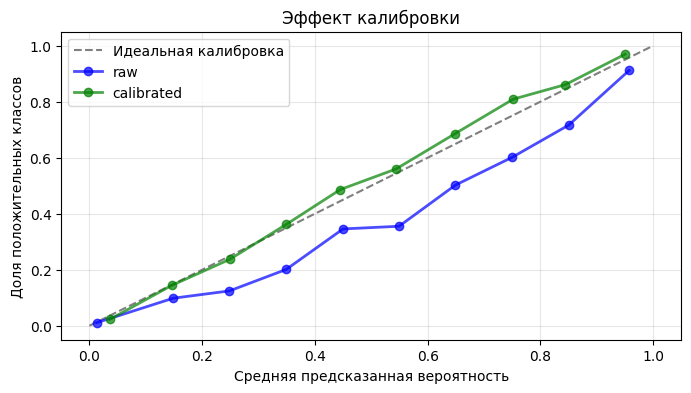

In [74]:
fop_orig_raw, mpv_orig_raw = calibration_curve(y_calib, y_prob_base, 
                                       n_bins=10)

fop_orig_calibrated, mpv_orig_calibrated = calibration_curve(y_calib, y_prob_calib, 
                                       n_bins=10)

# График
display_setup = ["blue", "green"]

plt.figure(figsize=(8, 4))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Идеальная калибровка')

plt.plot(mpv_orig_raw, fop_orig_raw, marker='o', linewidth=2, 
         label="raw", alpha=0.7, color=display_setup[0])

plt.plot(mpv_orig_calibrated, fop_orig_calibrated, marker='o', linewidth=2, 
         label="calibrated", alpha=0.7, color=display_setup[1])

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Эффект калибровки')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [75]:
brier_uncal = brier_score_loss(y_calib, y_prob_base)
brier_cal = brier_score_loss(y_calib, y_prob_calib)

print(f"Brier score (некалиброванная): {brier_uncal:.4f}")
print(f"Brier score (калиброванная): {brier_cal:.4f}")

Brier score (некалиброванная): 0.1283
Brier score (калиброванная): 0.1202


Модель изначально была неплохо откалибрована, дополнительная калибровка незначительно улучшила модель

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

In [76]:
def find_threshold(y_true, y_proba):
    unique_thresholds = np.linspace(0, 1, 1001)
    
    best_ir = -np.inf

    for threshold in unique_thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        ir = incremental_revenue(y_true, y_pred)
        
        if ir > best_ir:
            best_ir = ir
            best_threshold = threshold

    print(f"Лучший порог: {best_threshold:.3f}")
    print(f"Лучшее значение Rel_IR при найденном пороге: {best_ir:.0f}") 
    return best_threshold

In [77]:
y_proba_calib = calibrated_pipe.predict_proba(X_calib)[:, 1]
y_pred_calib = calibrated_pipe.predict(X_calib)
print(f"IR при базовом пороге 0.5: {incremental_revenue(y_calib, y_pred_calib):.2f}\n")
threshold = find_threshold(y_calib, y_proba_calib)

IR при базовом пороге 0.5: 86736000.00

Лучший порог: 0.401
Лучшее значение Rel_IR при найденном пороге: 95905500


Полученное значение порога  0.401 означает, что если модель прогнозирует вероятность отмены больше  0.401, тогда модель классифицирует эту бронь как будущую отмену.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

In [78]:
y_pred_calib_with_t = (calibrated_pipe.predict_proba(X_calib)[:, 1] > threshold).astype(int)
y_pred_test_with_t = (calibrated_pipe.predict_proba(X_test)[:, 1] > threshold).astype(int)

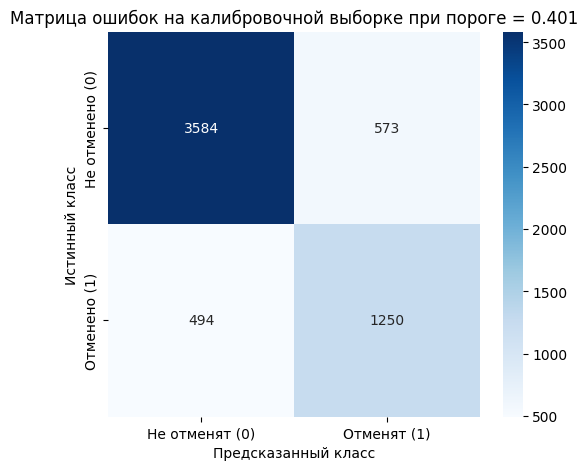

In [79]:
cm = confusion_matrix(y_calib, y_pred_calib_with_t)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не отменят (0)', 'Отменят (1)'],
            yticklabels=['Не отменено (0)', 'Отменено (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок на калибровочной выборке при пороге = {threshold:.3f}')
plt.show()

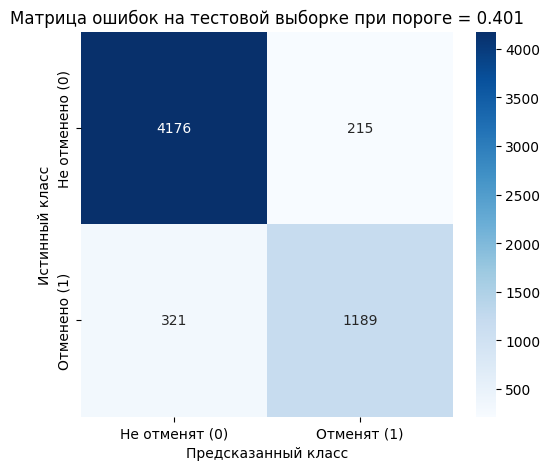

In [80]:
cm = confusion_matrix(y_test, y_pred_test_with_t)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не отменят (0)', 'Отменят (1)'],
            yticklabels=['Не отменено (0)', 'Отменено (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок на тестовой выборке при пороге = {threshold:.3f}')
plt.show()

  - Модель достаточно хорошо определяет бронирования которые не будут отменены:
    - На калибровочной выборке модель неверно предсказала 12.1% бронирований, которые НЕ посчитала рискованными, однако, эти бронирования были отменены
    - На тестовой выборке модель неверно предсказала 7.1% бронирований, которые НЕ посчитала рискованными, однако, эти бронирования были отменены 
  - Модель недостаточно стабильно определяет отмену бронирования:
    - На калибровочной выборке модель неверно предсказала 31.4% бронирований, которые посчитала рискованными, но в конечном итоге эти бронирования не были отменены
    -  На тестовой выборке модель неверно предсказала 15.3% бронирований, которые посчитала рискованными, но в конечном итоге эти бронирования не были отменены

### Фиксирование итоговой модели

In [81]:
print(f"ROC_AUC на тестовой выборке: {roc_auc_score(y_test, y_pred_test_with_t):.2f}")
print(f"PR_AUC на тестовой выборке: {average_precision_score(y_test, y_pred_test_with_t):.2f}")

print('\nОтчет о классификации:')
print(classification_report(y_test, y_pred_test_with_t))

ROC_AUC на тестовой выборке: 0.87
PR_AUC на тестовой выборке: 0.72

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4391
           1       0.85      0.79      0.82      1510

    accuracy                           0.91      5901
   macro avg       0.89      0.87      0.88      5901
weighted avg       0.91      0.91      0.91      5901



- Зафиксисруйте лучшую модель и найденный порог.


    Наилучшей моделью с точки зрения максимального IR оказалась CatBoost с порогом классификации 0.415
    Метрики, полученные на тестовой выборке следующие:
      - ROC_AUC: 0.87
      - PR_AUC: 0.72
    Из матрицы ошибок модели на тестовой и калибровочной выборках видно, что модель достаточно хорошо и стабильно определяет бронирования которые не будут отменены (ошибочны 7.1-12.1%). При этом модель недостаточно нестабильна при определении отмены бронирования (ошибочны 15.3% - 31.4%)

### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

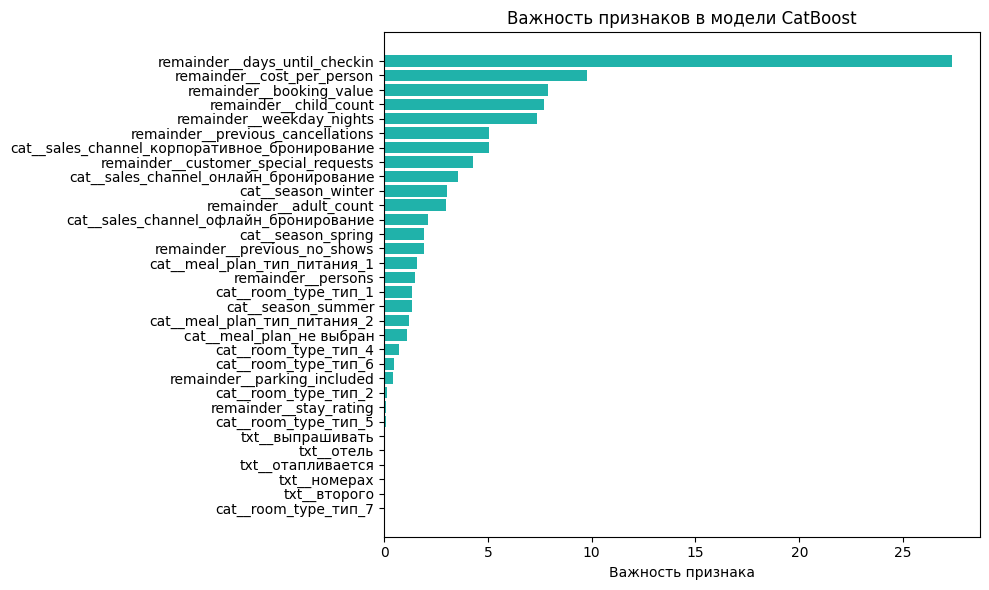

In [82]:
feature_importance = pd.DataFrame({
    "feature": calibrated_pipe.calibrated_classifiers_[0].estimator.named_steps['preprocessor'].get_feature_names_out(),
    "importance": calibrated_pipe.calibrated_classifiers_[0].estimator.named_steps['Catboost'].feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    y=feature_importance["feature"][::-1],
    width=feature_importance["importance"][::-1],
    color='lightseagreen'
)
plt.xlabel("Важность признака")
plt.title("Важность признаков в модели CatBoost")
plt.tight_layout()
plt.show()

Топ-5 наиболее важными признаками для модели являются:
  - Количество дней до заселения: логично - чем меньше дней до заселения - тем больше клиенты уверены в своем выборе и меньше непредсказумых событий из-за которых бронь может быть отменена
  - Стоимость бронирования: скорее всего люди, бронирующие дорогие номера, имеют более стабильные планы и меньше подвержены импульсивным отменам
  - Количество детей: скорее всего родители с детьми предъявляют повышенные требования к условиям и потому по возможности стараются найти отель еще лучше, а потому могут отменять бронирвоние
  - Количество ночей в периоде проживания, которые приходятся на будние дни: чем меньше количество дней для проживания забронировано - тем вероятнее будет отмена
  - Количество отмененных бронирований у клиента в прошлом: чем чаще клиент отменял бронирование в прошлом - тем выше шанс что он отменит и следующее

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


In [83]:
# Доля отмен бронирования
cancel_rate_before = y_test.mean()
fn = np.sum((y_test == 1) & (y_pred_test_with_t == 0))
total = len(y_test)
cancel_rate_after = fn / total

# Доля занятых номеров
occupied_before = np.sum(y_test == 0)
occupied_after = np.sum((y_test == 0) & (y_pred_test_with_t == 0))
rel_occupied = (occupied_after - occupied_before) / occupied_before * 100

rel_ir = relative_incremental_revenue(y_test, y_pred_test_with_t)

In [84]:
print(f"Доля отмен бронирования до внедрения модели: {cancel_rate_before:.4f}")
print(f"Доля отмен бронирования после внедрения модели: {cancel_rate_after:.4f}")
print(f"\nДоля занятых номеров после внедрения модели: {occupied_before / len(y_test) :.3f}")
print(f"Доля занятых номеров после внедрения модели: {occupied_after / len(y_pred_test_with_t) :.3f}")

Доля отмен бронирования до внедрения модели: 0.2559
Доля отмен бронирования после внедрения модели: 0.0544

Доля занятых номеров после внедрения модели: 0.744
Доля занятых номеров после внедрения модели: 0.708


In [85]:
print(f'Относительный IR: {rel_ir:.2f}%')
print(f'Доля отмен после внедрения модели: {cancel_rate_after*100:.2f}%')
print(f'Относительная загрузка отеля: {rel_occupied:.2f}%')

Относительный IR: 61.79%
Доля отмен после внедрения модели: 5.44%
Относительная загрузка отеля: -4.90%


Все метрики на тестовой метрике с порогом классификации 0.415 удовлетворяет требованиям успешности проекта:
  - Доля отмен после внедрения модели: 5.44% - требование в 10% после внедрения модели ВЫПОЛНЕНО
  - Относительная загрузка отеля: -4.90% - требование о неуменьшении загрузки отеля больше чем на 8% после внедрения модели ВЫПОЛНЕНО
  - Относительный IR: 61.79% - требование об относительным IR не менее 50% ВЫПОЛНЕНО

## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

В процессе подготовки данных были выгруженны 2 таблицы: первая - с данными о 35_341 наблюдениями о бронировании номеров отеля за период с 01.01.2017 до 22.10.2025, вторая таблица представляет собой 25_177 записей относительно данных об отзывах клиентов и их оценка отеля за период с 17.01.2017 до 03.03.2026

В результате объединения таблиц, обработки дубликатов и пустых значений, общее количество записей составило 29_504

Были созданы следующие признаки:
  - cost_per_person - стоимость бронирования на человека (без разделения на взрослых и детей)
  - season - время года когда было осуществленно бронирование
  - persons - общее количество людей
  - 5 признаков, отражающих значение tf-idf для наиболее часто встречающихся слов

Наилучшей моделью с точки зрения максимального IR оказалась CatBoost с порогом классификации 0.415

Метрики, полученные на тестовой выборке следующие:
  - ROC_AUC : 0.87
  - PR_AUC : 0.72

Метрики, полученные на тестовой выборке остались на уровне тренировчной, что свидетельствует об отсутсвии переобучения

5-ю наиболее важными признаками для модели являются:
  - Количество дней до заселения: логично - чем меньше дней до заселения - тем больше клиенты уверены в своем выборе и меньше непредсказумых событий из-за которых бронь может быть отменена
  - Стоимость бронирования: скорее всего люди, бронирующие дорогие номера, имеют более стабильные планы и меньше подвержены импульсивным отменам
  - Количество детей: скорее всего родители с детьми предъявляют повышенные требования к условиям и потому по возможности стараются найти отель еще лучше, а потому могут отменять бронирвоние
  - Количество ночей в периоде проживания, которые приходятся на будние дни: чем меньше количество дней для проживания забронировано - тем вероятнее будет отмена
  - Количество отмененных бронирований у клиента в прошлом: чем чаще клиент отменял бронирование в прошлом - тем выше шанс что он отменит и следующее

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

Все три ключевые метрики удовлетворяют требованиям успешности проекта:
  - Доля отмен после внедрения модели: 5.44% - требование в 10% после внедрения модели ВЫПОЛНЕНО
  - Относительная загрузка отеля: -4.90% - требование о неуменьшении загрузки отеля больше чем на 8% после внедрения модели ВЫПОЛНЕНО
  - Относительный IR: 61.79% - требование об относительным IR не менее 50% ВЫПОЛНЕНО

Рост метрик до и после внедрения модели:
Доля отмен бронирования:  25.59% -> 5.44%
Доля занятых номеров: 74.4% -> 70.8%
IR: 185_824_500 -> 300_647_500